# Longstaff-Schwartz Methods (Regression-Based Methods)

In this notebook, I implement the Least-Squares methods for American put option pricing.
The content of this notebook is based on "Valuing American Options by Simulation: A Simple Least-Squares Approach" by Longstaﬀ and Schwartz.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Parameters

In [2]:
num_basis = 4

In [3]:
time_step = 0.25
terminal_time = 1
time_grid = np.arange(0, terminal_time + time_step, time_step)
num_steps = len(time_grid)

num_total_samples = 10000

initial_stock_price = 100
riskless = 0.03
strike_price = 100

# volatility
sigma = 0.2

# 2. Functions

In [4]:
# basis_funcs[k](x) = (x/K)^k
basis_funcs = []
for i in range(num_basis):
    basis_funcs.append(lambda x, i=i: (x / strike_price) ** i)

In [5]:
def put_intrinsic_value(current_price):
    return max(0, strike_price - current_price)

# 3. Simulation of stock price paths

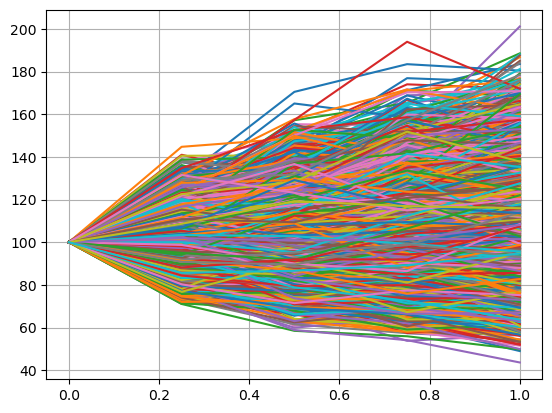

In [6]:
stock_price = np.zeros((num_total_samples, num_steps))
W = np.zeros((num_total_samples, num_steps))
for i in range(num_total_samples):
    for j in range(num_steps-1):
        Z = np.random.normal(loc=0,scale=1)
        W[i][j+1] = W[i][j] + np.sqrt(time_grid[j+1] - time_grid[j]) * Z

for i in range(num_total_samples):
    stock_price[i][0] = initial_stock_price
    for j in range(1,num_steps):
        stock_price[i][j] = initial_stock_price * np.exp((riskless - 1/2 * sigma**2) * time_grid[j] + sigma * W[i][j])

for i in range(num_total_samples):
    plt.plot(time_grid, stock_price[i])
plt.grid(True)
plt.show()

# 4. Backward Induction

In [7]:
intrinsic_value = np.zeros((num_total_samples, num_steps))

for i in range(num_total_samples):
    for j in range(num_steps):
        intrinsic_value[i][j] = put_intrinsic_value(stock_price[i][j])

cashflow_matrix = np.zeros((num_total_samples, num_steps))
cashflow_matrix[:, num_steps - 1] = intrinsic_value[:, num_steps - 1]

for j in reversed(range(1, num_steps - 1)):
    coeff_vec = np.zeros(num_basis)
    B_psi_V = np.zeros(num_basis)
    B_psi = np.zeros((num_basis, num_basis))
    X = np.array([])
    Y = np.array([])

    for i in range(num_total_samples):
        if intrinsic_value[i][j] != 0:
            future_cashflows = cashflow_matrix[i][j+1:]
            nonzero_index = np.nonzero(future_cashflows)[0]
            if len(nonzero_index) > 0:
                first_future_index = (nonzero_index[0]+(j+1))
                discounted_future_cashflow = (
                    np.exp(-riskless * time_step * (first_future_index - j))
                    * cashflow_matrix[i][first_future_index]
                )
                X = np.append(X, stock_price[i][j])
                Y = np.append(Y,discounted_future_cashflow)
                
    length = len(X)

    for i in range(length):
        for q in range(num_basis):
            for r in range(num_basis):
                B_psi[q][r] += basis_funcs[q](X[i]) * basis_funcs[r](X[i])
            B_psi_V[q] += basis_funcs[q](X[i]) * Y[i]
    B_psi /= length
    B_psi_V /= length
    B_psi_inv = np.linalg.pinv(B_psi)
    coeff_vec = np.dot(B_psi_inv, B_psi_V)
    
    for i in range(num_total_samples):
        if intrinsic_value[i][j] != 0:
            vector = np.array([
                basis_funcs[m](stock_price[i][j])
                for m in range(num_basis)
            ])
            continuation_value = np.dot(coeff_vec, vector)
            if intrinsic_value[i][j]> continuation_value:
                cashflow_matrix[i][j] = (intrinsic_value[i][j])
                cashflow_matrix[i][j+1:num_steps] = np.zeros(num_steps-(j+1))
        else:
            cashflow_matrix[i][j] = 0

# 5. Computation of the estimator

In [8]:
discount_factor = np.zeros((num_total_samples, num_steps))

for j in range(num_steps):
    x = np.exp(- riskless * time_step * j)
    discount_factor[:,j] = np.full(shape=num_total_samples, fill_value=x, dtype=np.float64)

premium_estimator = 0
for i in range(num_total_samples):
    for j in range(num_steps):
        premium_estimator += discount_factor[i][j] * cashflow_matrix[i][j]

premium_estimator = premium_estimator/num_total_samples

print(premium_estimator)

6.7576052424589825


# References

1. F. A. Longstaﬀ and E. S. Schwartz. Valuing American Options by Simulation: A Simple Least-Squares Approach. *The Review of Financial Studies*, 14(1):113–147, 2001.